# Class-Level Analysis: FAVOR / AGAINST / NONE

**Goal:** Understand which stance classes each model struggles with, and whether larger models (e.g. Qwen3-14B) over-predict the NONE class compared to smaller ones (e.g. Qwen3-8B).

**Prompt:** `default` only (baseline, no examples).  
**Closed models:** claude-haiku-4-5-20251001, gpt-5.2, gpt-5-mini  
**Open models:** everything else

In [127]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

RUNS_ROOT    = Path('../data_out/semeval_results')
LABELS       = ['FAVOR', 'AGAINST', 'NONE']
CLOSED       = ['claude-haiku-4-5-20251001', 'gpt-5.2', 'gpt-5-mini']
CLASS_COLORS = {'FAVOR': 'steelblue', 'AGAINST': 'tomato', 'NONE': 'gray'}

---
## 0. Overview: Macro F1 Across Prompts and Shot Counts

**Chart a** — each line is a prompting method; models on x-axis sorted by mean F1.  
**Chart b** — each line is a model; x-axis runs from 0 shots (task definition) → 15 shots.

In [128]:
# ── Load macro F1 for every (model, prompt) combination ──────────────────────
from sklearn.metrics import f1_score as sk_f1

ALL_CHART_PROMPTS = [
    'default_no_label_definitions', 'default', 'task_definition',
    'question', 'cot', 'task_definition_scale',
    'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15',
    'semantic_icl_3', 'semantic_icl_6', 'semantic_icl_9', 'semantic_icl_12', 'semantic_icl_15',
]

overview_rows = []
for folder in sorted(RUNS_ROOT.iterdir()):
    if not folder.is_dir() or '_testdata_gold_' not in folder.name:
        continue
    if not (folder / 'document_assignments.csv').exists():
        continue
    rest  = folder.name.split('_testdata_gold_')[1]
    model_name, prompt_name = rest.split('_equal_', 1)
    if prompt_name not in ALL_CHART_PROMPTS:
        continue
    df = pd.read_csv(folder / 'document_assignments.csv',
                     usecols=['original_stance', 'predicted_stance'])
    df = df.dropna(subset=['predicted_stance'])
    if len(df) == 0:
        continue
    macro_f1 = sk_f1(df['original_stance'], df['predicted_stance'],
                     labels=LABELS, average='macro', zero_division=0)
    overview_rows.append({'model': model_name, 'prompt': prompt_name, 'macro_f1': macro_f1})

overview = pd.DataFrame(overview_rows)

# Short display names shared by both charts
SHORT = {
    'claude-haiku-4-5-20251001':   'Claude Haiku',
    'gpt-5.2':                      'GPT-5.2',
    'gpt-5-mini':                   'GPT-5-mini',
    'Qwen3-1.7B':                   'Qwen3-1.7B',
    'Qwen3-4B':                     'Qwen3-4B',
    'Qwen3-4B-Instruct-2507':       'Qwen3-4B-v2',
    'Qwen3-8B':                     'Qwen3-8B',
    'Qwen3-14B':                    'Qwen3-14B',
    'DeepSeek-R1-Distill-Llama-8B': 'DS-Llama-8B',
    'DeepSeek-R1-Distill-Qwen-14B': 'DS-Qwen-14B',
    'Llama-3.1-8B-Instruct':        'Llama-3.1-8B',
    'phi-4':                        'Phi-4',
    'phi-4-mini-instruct':          'Phi-4-mini',
    'Nemotron-Mini-4B-Instruct':    'Nemotron-4B',
}

print(f"Loaded {overview['model'].nunique()} models × {overview['prompt'].nunique()} prompts "
      f"({len(overview)} total combinations)")

Loaded 14 models × 16 prompts (164 total combinations)


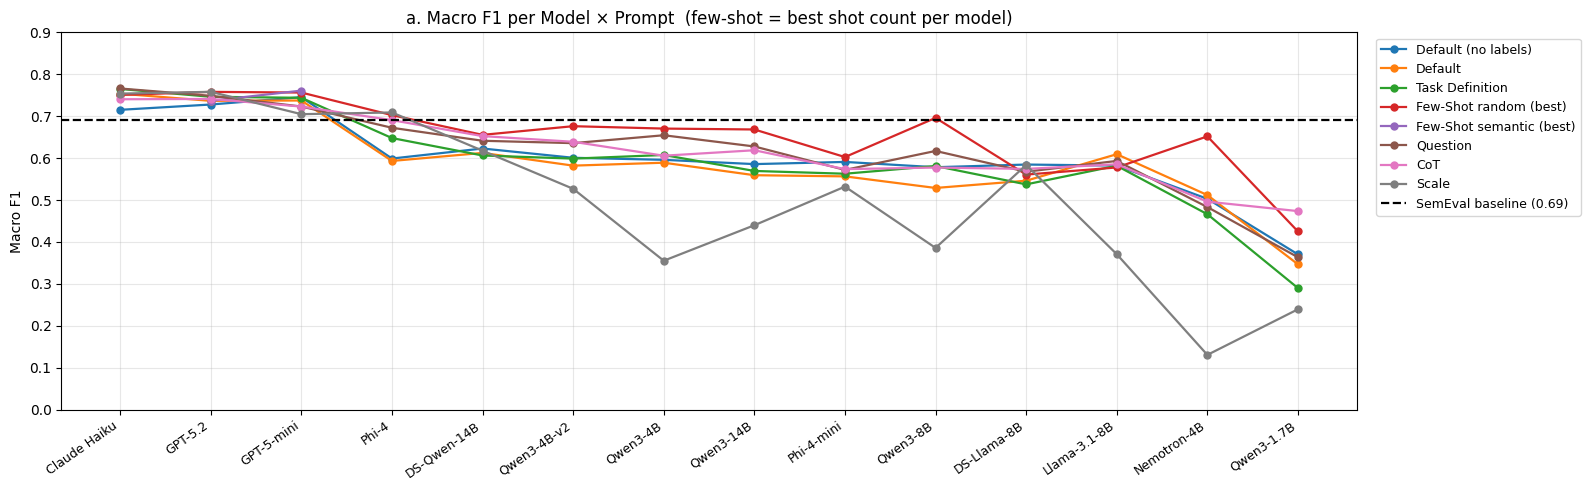


Best shot count per model:
       Model  Random (best n) Semantic (best n)
 DS-Llama-8B                9                 -
 DS-Qwen-14B               12                 -
Llama-3.1-8B                6                 -
 Nemotron-4B               12                 -
  Qwen3-1.7B               12                 -
   Qwen3-14B               12                 -
    Qwen3-4B               12                 -
 Qwen3-4B-v2                9                 -
    Qwen3-8B               12                 -
Claude Haiku               12                 -
  GPT-5-mini                9                 9
     GPT-5.2                6                12
       Phi-4                6                 -
  Phi-4-mini                6                 -


In [129]:
# ── Chart a: Macro F1 across all models, one line per prompt ─────────────────
BASELINE = 0.69

FEW_SHOT_PROMPTS    = ['few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15']
SEMANTIC_ICL_PROMPTS = ['semantic_icl_3', 'semantic_icl_6', 'semantic_icl_9', 'semantic_icl_12', 'semantic_icl_15']
SHOT_N = {'few_shot_3': 3, 'few_shot_6': 6, 'few_shot_9': 9,
          'few_shot_12': 12, 'few_shot_15': 15,
          'semantic_icl_3': 3, 'semantic_icl_6': 6, 'semantic_icl_9': 9,
          'semantic_icl_12': 12, 'semantic_icl_15': 15}

# Best few-shot per model — also record which shot count won
few_shot_data    = overview[overview['prompt'].isin(FEW_SHOT_PROMPTS)].copy()
semantic_icl_data = overview[overview['prompt'].isin(SEMANTIC_ICL_PROMPTS)].copy()
semantic_icl_data['n'] = semantic_icl_data['prompt'].map(SHOT_N)
few_shot_data['n'] = few_shot_data['prompt'].map(SHOT_N)

few_best_rows = []
for model, grp in few_shot_data.groupby('model'):
    best_row = grp.loc[grp['macro_f1'].idxmax()]
    few_best_rows.append({'model': model, 'macro_f1': best_row['macro_f1'],
                          'best_n': int(best_row['n']), 'prompt': 'few_shot_best'})
few_best     = pd.DataFrame(few_best_rows)
best_n_map     = few_best.set_index('model')['best_n'].to_dict()  # model → best shot count (random)
sem_best_n_map = {}  # filled after sem_best is built

sem_best_rows = []
for model, grp in semantic_icl_data.groupby('model'):
    best_row = grp.loc[grp['macro_f1'].idxmax()]
    sem_best_rows.append({'model': model, 'macro_f1': best_row['macro_f1'],
                          'best_n': int(best_row['n']), 'prompt': 'semantic_icl_best'})
sem_best       = pd.DataFrame(sem_best_rows)
sem_best_n_map = sem_best.set_index('model')['best_n'].to_dict()  # model → best shot count (semantic)

# Non-few-shot prompts
base_prompts = ['default_no_label_definitions', 'default', 'task_definition',
                'question', 'cot', 'task_definition_scale']
chart_a = pd.concat([overview[overview['prompt'].isin(base_prompts)],
                     few_best[['model', 'macro_f1', 'prompt']],
                     sem_best[['model', 'macro_f1', 'prompt']]], ignore_index=True)

# Model order: sort by mean F1 across all prompts (best → worst)
model_order = (chart_a.groupby('model')['macro_f1'].mean()
               .sort_values(ascending=False).index.tolist())

PROMPT_ORDER = ['default_no_label_definitions', 'default', 'task_definition',
                'few_shot_best', 'semantic_icl_best', 'question', 'cot', 'task_definition_scale']
PROMPT_LABEL = {
    'default_no_label_definitions': 'Default (no labels)',
    'default':                      'Default',
    'task_definition':              'Task Definition',
    'few_shot_best':                'Few-Shot random (best)',
    'semantic_icl_best':            'Few-Shot semantic (best)',
    'question':                     'Question',
    'cot':                          'CoT',
    'task_definition_scale':        'Scale',
}

prompt_colors = [plt.cm.tab10(i) for i in range(8)]

fig, ax = plt.subplots(figsize=(16, 5))

for i, prompt in enumerate(PROMPT_ORDER):
    sub_dict = (chart_a[chart_a['prompt'] == prompt]
                .set_index('model')['macro_f1'].to_dict())
    y = [sub_dict.get(m, np.nan) for m in model_order]
    ax.plot(model_order, y, marker='o', markersize=5, linewidth=1.6,
            color=prompt_colors[i], label=PROMPT_LABEL[prompt])


ax.axhline(BASELINE, color='black', linestyle='--', linewidth=1.6,
           label='SemEval baseline (0.69)')

ax.set_xticks(range(len(model_order)))
ax.set_xticklabels([SHORT.get(m, m) for m in model_order],
                   rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Macro F1')
ax.set_title('a. Macro F1 per Model × Prompt  (few-shot = best shot count per model)')
ax.set_ylim(0, 0.9)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True, fontsize=9)

plt.tight_layout()
plt.show()
# ── Best shot count summary table ────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':        [SHORT.get(m, m) for m in best_n_map],
    'Random (best n)':   list(best_n_map.values()),
    'Semantic (best n)': [sem_best_n_map.get(m, '-') for m in best_n_map],
})
print("\nBest shot count per model:")
print(summary.to_string(index=False))


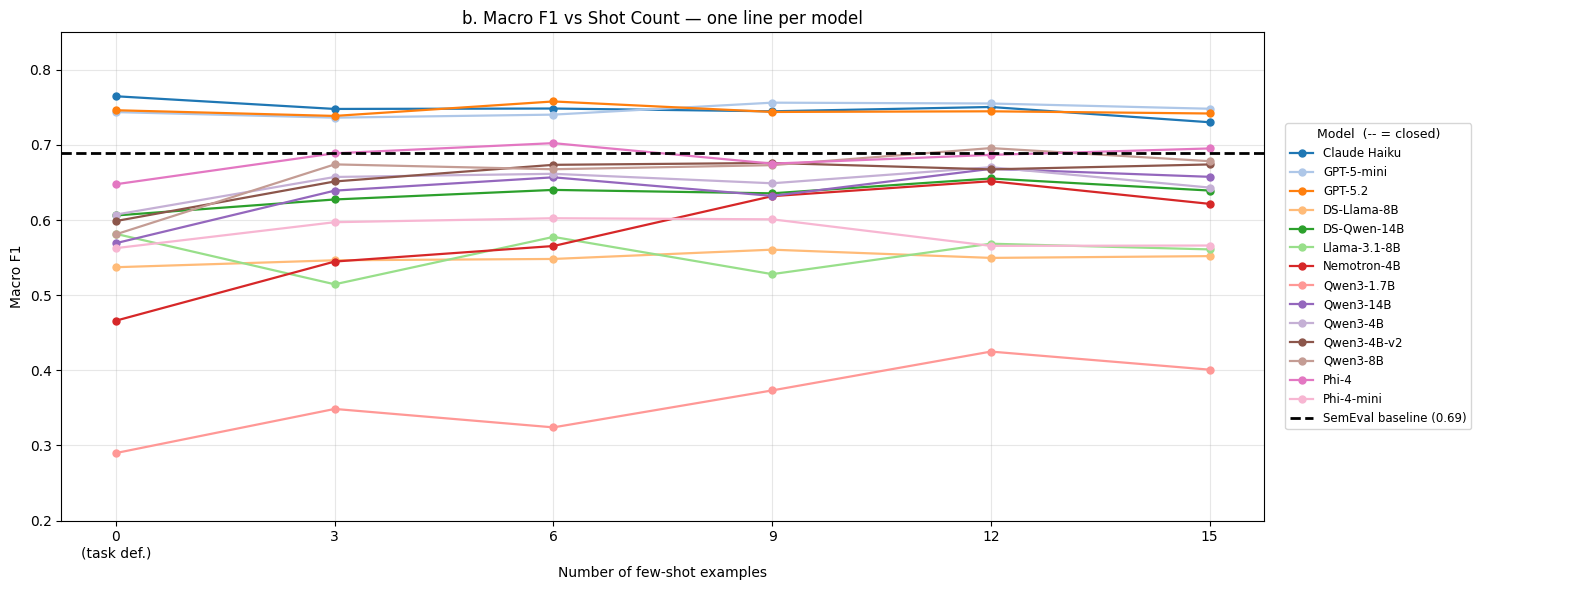

In [130]:
# ── Chart b: Macro F1 vs shot count, one line per model ──────────────────────
SHOT_PROMPTS = ['task_definition', 'few_shot_3', 'few_shot_6',
                'few_shot_9', 'few_shot_12', 'few_shot_15']
SHOT_X       = {'task_definition': 0, 'few_shot_3': 3, 'few_shot_6': 6,
                'few_shot_9': 9, 'few_shot_12': 12, 'few_shot_15': 15}

chart_b = overview[overview['prompt'].isin(SHOT_PROMPTS)].copy()
chart_b['n_shots'] = chart_b['prompt'].map(SHOT_X)

# Model order: closed first, then open alphabetically
closed_models = sorted([m for m in chart_b['model'].unique() if m in CLOSED])
open_models   = sorted([m for m in chart_b['model'].unique() if m not in CLOSED])
model_list    = closed_models + open_models

# 14 colours from tab20; closed get dashed + bolder lines
import matplotlib.cm as cm
tab20 = [cm.tab20(i) for i in range(20)]
model_color = {m: tab20[i] for i, m in enumerate(model_list)}

fig, (ax, ax_leg) = plt.subplots(1, 2, figsize=(16, 6),
                                  gridspec_kw={'width_ratios': [4, 1]})

for model in model_list:
    sub = chart_b[chart_b['model'] == model].sort_values('n_shots')
    is_closed = model in CLOSED
    ax.plot(sub['n_shots'], sub['macro_f1'],
            marker='o', markersize=5,
            linewidth=1.6 if is_closed else 1.6,
            linestyle='-' if is_closed else '-',
            color=model_color[model],
            label=SHORT.get(model, model))

ax.axhline(BASELINE, color='black', linestyle='--', linewidth=2, label='SemEval baseline (0.69)')
ax.set_xticks([0, 3, 6, 9, 12, 15])
ax.set_xticklabels(['0\n(task def.)', '3', '6', '9', '12', '15'])
ax.set_xlabel('Number of few-shot examples')
ax.set_ylabel('Macro F1')
ax.set_title('b. Macro F1 vs Shot Count — one line per model')
ax.set_ylim(0.2, 0.85)
ax.grid(True, alpha=0.3)

ax_leg.axis('off')
handles, labels = ax.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center left', frameon=True,
              fontsize=8.5, title='Model  (-- = closed)', title_fontsize=9)

plt.tight_layout()
plt.show()

### 0.3  Three-class Macro F1 by Prompt — One Line per Model
All random shots (3R–15R) followed by all semantic shots (3S–15S).

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_17928/2103408259.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  open_cmap3  = cm.get_cmap('tab10')


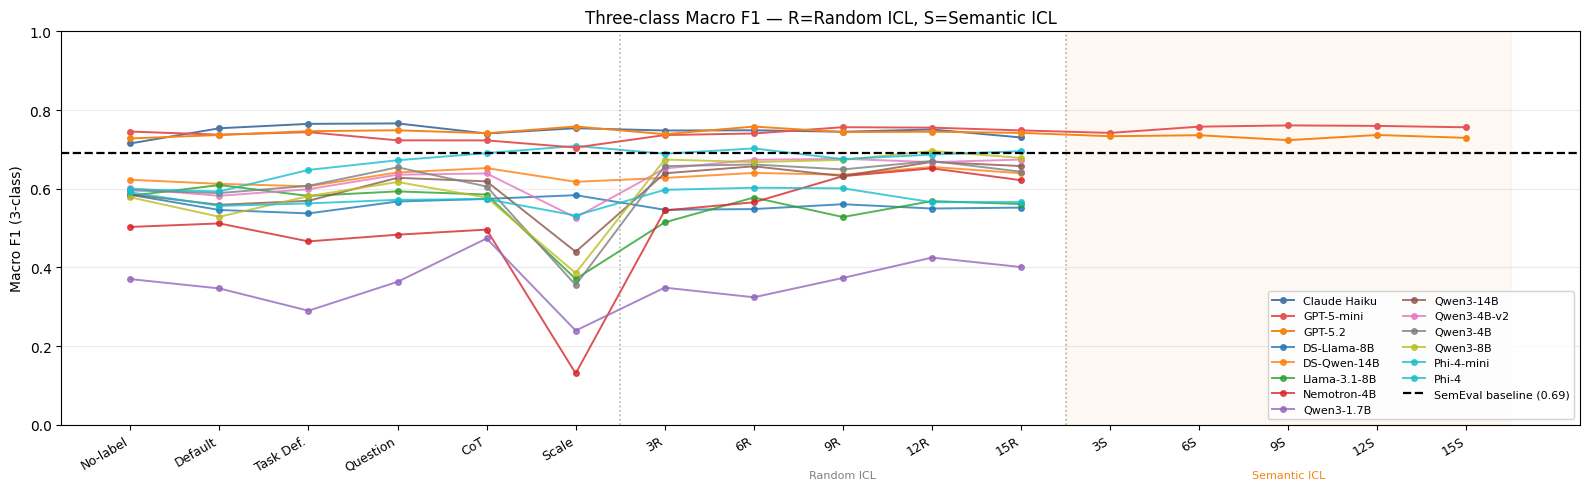

In [131]:
# ── Chart: Three-class Macro F1 — all prompts × models ───────────────────────
# Same layout as Chart c but using macro F1 across all three classes.

THREE_CLASS_PROMPT_ORDER = [
    'default_no_label_definitions', 'default', 'task_definition',
    'question', 'cot', 'task_definition_scale',
    'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15',
    'semantic_icl_3', 'semantic_icl_6', 'semantic_icl_9', 'semantic_icl_12', 'semantic_icl_15',
]
THREE_CLASS_PROMPT_LABELS = [
    'No-label', 'Default', 'Task Def.', 'Question', 'CoT', 'Scale',
    '3R', '6R', '9R', '12R', '15R',
    '3S', '6S', '9S', '12S', '15S',
]

# overview already loaded in cell 3 — filter to relevant prompts
three_class_df = overview[overview['prompt'].isin(THREE_CLASS_PROMPT_ORDER)].copy()

closed_in3 = [m for m in three_class_df['model'].unique() if m in CLOSED]
open_in3   = [m for m in three_class_df['model'].unique() if m not in CLOSED]

open_cmap3  = cm.get_cmap('tab10')
open_color3 = {m: open_cmap3(i / max(len(open_in3) - 1, 1)) for i, m in enumerate(open_in3)}

x_pos3 = list(range(len(THREE_CLASS_PROMPT_ORDER)))

fig, ax = plt.subplots(figsize=(16, 5))

for model in closed_in3:
    sub = (three_class_df[three_class_df['model'] == model]
           .drop_duplicates(subset=['prompt'])
           .set_index('prompt').reindex(THREE_CLASS_PROMPT_ORDER))
    ax.plot(x_pos3, sub['macro_f1'].values,
            color=CLOSED_COLORS_C.get(model, 'black'), linewidth=1.4,
            marker='o', markersize=4, label=SHORT.get(model, model), zorder=5)

for model in open_in3:
    sub = (three_class_df[three_class_df['model'] == model]
           .drop_duplicates(subset=['prompt'])
           .set_index('prompt').reindex(THREE_CLASS_PROMPT_ORDER))
    ax.plot(x_pos3, sub['macro_f1'].values,
            color=open_color3[model], linewidth=1.4,
            marker='o', markersize=4, alpha=0.8, label=SHORT.get(model, model))

ax.axhline(BASELINE, color='black', linestyle='--', linewidth=1.6,
           label=f'SemEval baseline ({BASELINE:.2f})')

ax.axvline(5.5,  color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
ax.axvline(10.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
ax.axvspan(10.5, 15.5, color='#F58518', alpha=0.05, zorder=0)

ax.text(8.0,  -0.115, 'Random ICL',   ha='center', va='top',
        fontsize=8, color='gray', transform=ax.get_xaxis_transform())
ax.text(13.0, -0.115, 'Semantic ICL', ha='center', va='top',
        fontsize=8, color='#F58518', transform=ax.get_xaxis_transform())

ax.set_xticks(x_pos3)
ax.set_xticklabels(THREE_CLASS_PROMPT_LABELS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Macro F1 (3-class)')
ax.set_ylim(0, 1.0)
ax.set_title('Three-class Macro F1 — R=Random ICL, S=Semantic ICL')
ax.legend(loc='lower right', fontsize=8, ncol=2, framealpha=0.85)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.show()


### 0.3  Two-class F1 by Prompt — One Line per Model
Official SemEval metric: **F_average = (F_FAVOR + F_AGAINST) / 2** (NONE excluded).
Directly comparable to the Mohammad et al. (2016) SVM baseline (0.68).
Closed models = thick lines; open models = thinner tab10 lines.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_17928/337860524.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  open_cmap_c  = cm.get_cmap('tab10')


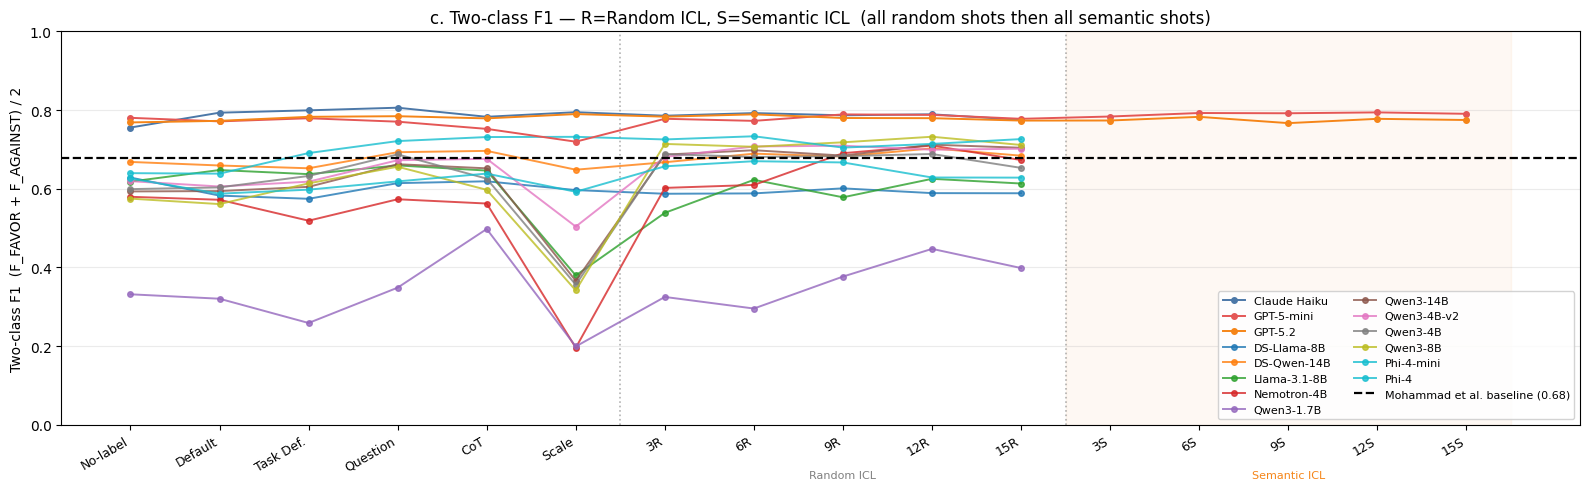

In [132]:
# ── Chart c: Two-class F1  (F_FAVOR + F_AGAINST)/2 — all prompts × models ──
# Matches the official SemEval 2016 metric; baseline from Mohammad et al. (2016).
# Shot counts interleaved: 3-shot random, 3-shot semantic, 6-shot random, ...
from sklearn.metrics import f1_score as sk_f1
import matplotlib.cm as cm

TWO_CLASS_PROMPT_ORDER = [
    'default_no_label_definitions', 'default', 'task_definition',
    'question', 'cot', 'task_definition_scale',
    'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15',
    'semantic_icl_3', 'semantic_icl_6', 'semantic_icl_9', 'semantic_icl_12', 'semantic_icl_15',
]
TWO_CLASS_PROMPT_LABELS = [
    'No-label', 'Default', 'Task Def.', 'Question', 'CoT', 'Scale',
    '3R', '6R', '9R', '12R', '15R',
    '3S', '6S', '9S', '12S', '15S',
]
MOHAMMAD_BASELINE = 0.6782  # Mohammad et al. (2016): (F_FAVOR + F_AGAINST) / 2

two_class_rows = []
seen_tc = set()
for folder in sorted(RUNS_ROOT.iterdir()):
    if not folder.is_dir() or '_testdata_gold_' not in folder.name:
        continue
    if not (folder / 'document_assignments.csv').exists():
        continue
    rest = folder.name.split('_testdata_gold_')[1]
    model_name, prompt_name = rest.split('_equal_', 1)
    if prompt_name not in TWO_CLASS_PROMPT_ORDER:
        continue
    if (model_name, prompt_name) in seen_tc:
        continue
    seen_tc.add((model_name, prompt_name))
    df = pd.read_csv(folder / 'document_assignments.csv',
                     usecols=['original_stance', 'predicted_stance'])
    df = df.dropna(subset=['predicted_stance'])
    if len(df) == 0:
        continue
    two_class_f1 = sk_f1(df['original_stance'], df['predicted_stance'],
                         labels=['FAVOR', 'AGAINST'], average='macro', zero_division=0)
    two_class_rows.append({'model': model_name, 'prompt': prompt_name,
                           'two_class_f1': two_class_f1})

two_class_df = pd.DataFrame(two_class_rows)

closed_in = [m for m in two_class_df['model'].unique() if m in CLOSED]
open_in   = [m for m in two_class_df['model'].unique() if m not in CLOSED]
CLOSED_COLORS_C = {
    'claude-haiku-4-5-20251001': '#4C78A8',
    'gpt-5.2':                   '#F58518',
    'gpt-5-mini':                '#E45756',
}
open_cmap_c  = cm.get_cmap('tab10')
open_color_c = {m: open_cmap_c(i / max(len(open_in) - 1, 1)) for i, m in enumerate(open_in)}

x_pos = list(range(len(TWO_CLASS_PROMPT_ORDER)))

fig, ax = plt.subplots(figsize=(16, 5))

for model in closed_in:
    sub = (two_class_df[two_class_df['model'] == model]
           .drop_duplicates(subset=['prompt'])
           .set_index('prompt').reindex(TWO_CLASS_PROMPT_ORDER))
    ax.plot(x_pos, sub['two_class_f1'].values,
            color=CLOSED_COLORS_C.get(model, 'black'), linewidth=1.4,
            marker='o', markersize=4, label=SHORT.get(model, model), zorder=5)

for model in open_in:
    sub = (two_class_df[two_class_df['model'] == model]
           .drop_duplicates(subset=['prompt'])
           .set_index('prompt').reindex(TWO_CLASS_PROMPT_ORDER))
    ax.plot(x_pos, sub['two_class_f1'].values,
            color=open_color_c[model], linewidth=1.4,
            marker='o', markersize=4, alpha=0.8, label=SHORT.get(model, model))

ax.axhline(MOHAMMAD_BASELINE, color='black', linestyle='--', linewidth=1.6,
           label=f'Mohammad et al. baseline ({MOHAMMAD_BASELINE:.2f})')

# Vertical separators: after zero-shot block and between random/semantic groups
ax.axvline(5.5,  color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
ax.axvline(10.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)

# Shade the semantic ICL block
ax.axvspan(10.5, 15.5, color='#F58518', alpha=0.05, zorder=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(TWO_CLASS_PROMPT_LABELS, rotation=30, ha='right', fontsize=9)

# Second x-axis label row showing shot count groups
ax.text(8.0,  -0.115, 'Random ICL',   ha='center', va='top',
        fontsize=8, color='gray', transform=ax.get_xaxis_transform())
ax.text(13.0, -0.115, 'Semantic ICL', ha='center', va='top',
        fontsize=8, color='#F58518', transform=ax.get_xaxis_transform())

ax.set_ylabel('Two-class F1  (F_FAVOR + F_AGAINST) / 2')
ax.set_ylim(0, 1.0)
ax.set_title('c. Two-class F1 — R=Random ICL, S=Semantic ICL  (all random shots then all semantic shots)')
ax.legend(loc='lower right', fontsize=8, ncol=2, framealpha=0.85)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.show()


In [133]:
# ── Summary table: 2-class F1 and 3-class F1 per model × prompt ──────────────
SHOT_PAIRS = [
    ('few_shot_3', 'semantic_icl_3'),
    ('few_shot_6', 'semantic_icl_6'),
    ('few_shot_9', 'semantic_icl_9'),
    ('few_shot_12', 'semantic_icl_12'),
    ('few_shot_15', 'semantic_icl_15'),
]
COL_ORDER  = [p for pair in SHOT_PAIRS for p in pair]
COL_LABELS = {
    'few_shot_3': '3R',    'semantic_icl_3':  '3S',
    'few_shot_6': '6R',    'semantic_icl_6':  '6S',
    'few_shot_9': '9R',    'semantic_icl_9':  '9S',
    'few_shot_12': '12R',  'semantic_icl_12': '12S',
    'few_shot_15': '15R',  'semantic_icl_15': '15S',
}

macro_pivot    = (overview[overview['prompt'].isin(COL_ORDER)]
                  .pivot_table(index='model', columns='prompt', values='macro_f1')
                  .reindex(columns=COL_ORDER))
two_class_pivot = (two_class_df[two_class_df['prompt'].isin(COL_ORDER)]
                   .pivot_table(index='model', columns='prompt', values='two_class_f1')
                   .reindex(columns=COL_ORDER))

macro_pivot.columns     = pd.MultiIndex.from_tuples([('3-class F1', COL_LABELS[c]) for c in COL_ORDER])
two_class_pivot.columns = pd.MultiIndex.from_tuples([('2-class F1', COL_LABELS[c]) for c in COL_ORDER])

summary_table = pd.concat([macro_pivot, two_class_pivot], axis=1)
summary_table.index = [SHORT.get(m, m) for m in summary_table.index]
summary_table = summary_table.sort_index()

display(summary_table.style
    .format('{:.3f}', na_rep='-')
    .set_caption('3-class Macro F1 and 2-class F1  (R=Random ICL, S=Semantic ICL, interleaved by shot count)')
)


## 1. Ground Truth Class Distribution

All models see the same test set, so we pull the ground truth from one model's data.

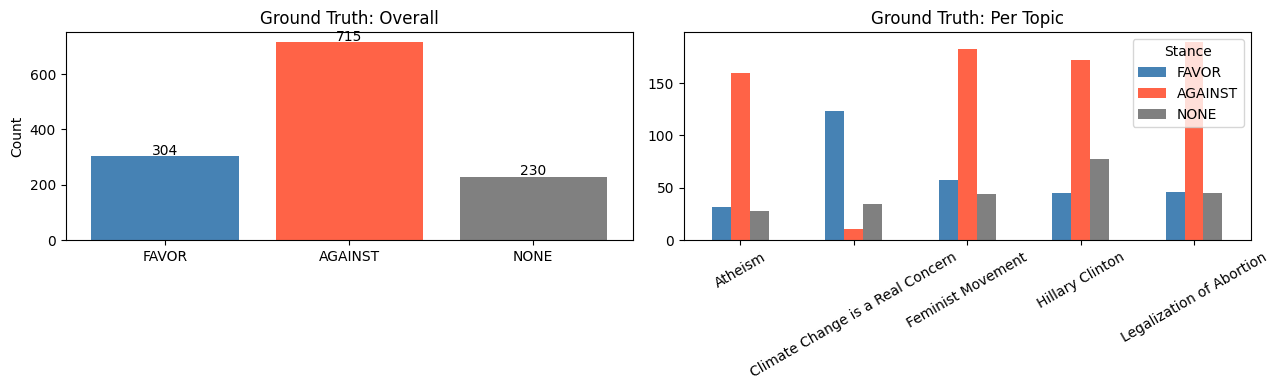

In [134]:
# ── 1. Ground Truth Class Distribution ───────────────────────────────────────
import pandas as pd
from pathlib import Path

# Load ground truth from any one run folder (labels are identical across all runs)
_gt_folder = next(
    f for f in sorted(RUNS_ROOT.iterdir())
    if f.is_dir() and '_testdata_gold_' in f.name
    and (f / 'document_assignments.csv').exists()
)
_gt_df = pd.read_csv(_gt_folder / 'document_assignments.csv',
                     usecols=['query', 'original_stance']).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall distribution
overall = _gt_df['original_stance'].value_counts()[LABELS]
axes[0].bar(LABELS, overall, color=[CLASS_COLORS[l] for l in LABELS])
for i, v in enumerate(overall):
    axes[0].text(i, v + 5, str(v), ha='center')
axes[0].set_title('Ground Truth: Overall')
axes[0].set_ylabel('Count')

# Per topic
topic_dist = (_gt_df.groupby(['query', 'original_stance'])
              .size().unstack(fill_value=0)[LABELS])
topic_dist.plot(kind='bar', ax=axes[1], color=[CLASS_COLORS[l] for l in LABELS])
axes[1].set_title('Ground Truth: Per Topic')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Stance')

plt.tight_layout()
plt.show()


---
## 2. Class Distribution Bias

**Hypothesis (Rogers & Zhang, 2025):** LLMs exhibit a systematic bias toward predicting the no-stance label (NONE), driven by safety alignment / guardrails.

**Bias score** = predicted class % − ground truth % for each (model, prompt) pair.
- Positive (+) = model over-predicts that class relative to the true distribution
- Negative (−) = model under-predicts it
- The three bias scores always sum to zero — it is a **zero-sum redistribution** across classes.

> **Terminology note:** Rogers & Zhang's "neutral" is an intermediate sentiment label. SemEval's NONE means *"the tweet takes no stance toward the topic"* — a legitimate gold-standard class, not a researcher-imposed middle ground. The mechanism is the same: do models hedge to the safe default label under uncertainty?

| Cell | Question |
|------|----------|
| 12.2 | Overall direction — is NONE systematically over-predicted? |
| 12.3 | Heatmap: NONE bias across all 14 models × 11 prompts |
| 12.4 | All 3 classes: the zero-sum redistribution |
| 12.5 | Is NONE bias linked to model type? (closed vs open) |
| 12.6 | Does few-shot prompting reduce NONE bias? |
| 12.7 | Precision/Recall signature of over-prediction |
| 12.8 | Does NONE bias hurt macro F1? (correlation) |
| 12.9 | Summary table ranked by NONE bias |

*For per-topic NONE breakdown see Section 10.*

In [135]:
# ── 2.0  Load all (model, prompt) data — bias scores, per-class F1, per-topic ─
from sklearn.metrics import classification_report as cl_report

ALL_PROMPTS_BIAS = [
    'default_no_label_definitions', 'default', 'task_definition',
    'question', 'cot', 'task_definition_scale',
    'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15',
]
SHORT_PROMPT = {
    'default_no_label_definitions': 'No-label',
    'default':               'Default',
    'task_definition':       'Task Def.',
    'question':              'Question',
    'cot':                   'CoT',
    'task_definition_scale': 'Scale',
    'few_shot_3':  '3-shot',  'few_shot_6':  '6-shot',  'few_shot_9':  '9-shot',
    'few_shot_12': '12-shot', 'few_shot_15': '15-shot',
}
TOPIC_SHORT = {
    'Atheism':                          'Atheism',
    'Climate Change is a Real Concern': 'Climate',
    'Feminist Movement':                'Feminist',
    'Hillary Clinton':                  'Hillary',
    'Legalization of Abortion':         'Abortion',
}

PROMPT_X_ORDER = [
    'default_no_label_definitions', 'default', 'task_definition',
    'question', 'cot', 'task_definition_scale',
    'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15',
]
PROMPT_X_LABELS = [
    'No-label', 'Default', 'Task Def.', 'Question', 'CoT', 'Scale',
    '3-shot', '6-shot', '9-shot', '12-shot', '15-shot',
]

bias_rows, pr_rows, topic_rows = [], [], []
seen = set()

for folder in sorted(RUNS_ROOT.iterdir()):
    if not folder.is_dir() or '_testdata_gold_' not in folder.name: continue
    if not (folder / 'document_assignments.csv').exists(): continue
    rest = folder.name.split('_testdata_gold_')[1]
    model_name, prompt_name = rest.split('_equal_', 1)
    if prompt_name not in ALL_PROMPTS_BIAS: continue
    if (model_name, prompt_name) in seen:
        print(f'  [skip duplicate] {model_name} / {prompt_name}')
        continue
    seen.add((model_name, prompt_name))

    df = pd.read_csv(folder / 'document_assignments.csv',
                     usecols=['original_stance', 'predicted_stance', 'query'])
    df = df.dropna(subset=['predicted_stance'])
    if len(df) == 0: continue

    gt   = df['original_stance'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100
    pred = df['predicted_stance'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100
    rep  = cl_report(df['original_stance'], df['predicted_stance'],
                     labels=LABELS, output_dict=True, zero_division=0)

    row = {'model': model_name, 'prompt': prompt_name}
    for label in LABELS:
        row[f'gt_{label}']   = gt[label]
        row[f'pred_{label}'] = pred[label]
        row[f'bias_{label}'] = pred[label] - gt[label]
        row[f'f1_{label}']   = rep[label]['f1-score']
        row[f'p_{label}']    = rep[label]['precision']
        row[f'r_{label}']    = rep[label]['recall']
    row['macro_f1'] = rep['macro avg']['f1-score']
    bias_rows.append(row)

    # Per-topic class distribution (for Section 15)
    for topic, tgrp in df.groupby('query'):
        tgt   = tgrp['original_stance'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100
        tpred = tgrp['predicted_stance'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100
        trow  = {'model': model_name, 'prompt': prompt_name,
                 'topic': TOPIC_SHORT.get(topic, topic)}
        for label in LABELS:
            trow[f'gt_{label}']   = tgt[label]
            trow[f'pred_{label}'] = tpred[label]
            trow[f'bias_{label}'] = tpred[label] - tgt[label]
        topic_rows.append(trow)

    for label in LABELS:
        pr_rows.append({
            'model': model_name, 'prompt': prompt_name, 'class': label,
            'precision': rep[label]['precision'],
            'recall':    rep[label]['recall'],
        })

bias_df       = pd.DataFrame(bias_rows)
pr_df         = pd.DataFrame(pr_rows)
topic_bias_df = pd.DataFrame(topic_rows)
pr_df['prompt_type'] = pr_df['prompt'].apply(
    lambda p: 'few-shot' if p.startswith('few_shot') else 'base')

GT_PCT = {label: bias_df[f'gt_{label}'].mean() for label in LABELS}
model_bias_order = (bias_df.groupby('model')['bias_NONE'].mean()
                    .sort_values(ascending=False).index.tolist())

print(f"Loaded {bias_df['model'].nunique()} models × {bias_df['prompt'].nunique()} prompts "
      f"= {len(bias_df)} combinations")
print(f"Ground truth:  FAVOR={GT_PCT['FAVOR']:.1f}%  "
      f"AGAINST={GT_PCT['AGAINST']:.1f}%  NONE={GT_PCT['NONE']:.1f}%")

Loaded 14 models × 11 prompts = 154 combinations
Ground truth:  FAVOR=24.3%  AGAINST=57.2%  NONE=18.4%


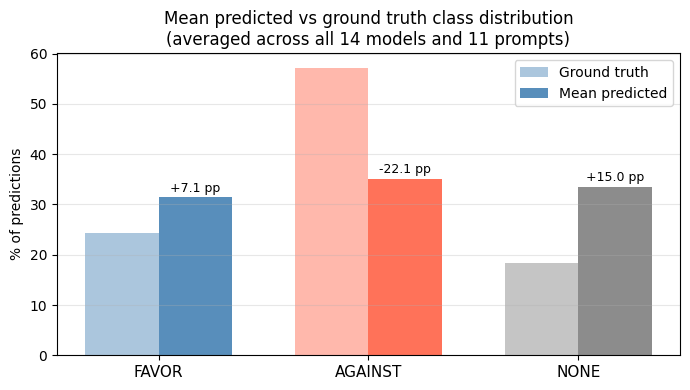

In [136]:
# ── 2.1  Overall direction: mean predicted % vs ground truth ─────────────────
mean_pred = {label: bias_df[f'pred_{label}'].mean() for label in LABELS}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, [GT_PCT[l]    for l in LABELS], w,
       color=[CLASS_COLORS[l] for l in LABELS], alpha=0.45, label='Ground truth')
ax.bar(x + w/2, [mean_pred[l] for l in LABELS], w,
       color=[CLASS_COLORS[l] for l in LABELS], alpha=0.9,  label='Mean predicted')

for i, label in enumerate(LABELS):
    diff = mean_pred[label] - GT_PCT[label]
    ax.annotate(f'{diff:+.1f} pp', xy=(x[i] + w/2, mean_pred[label]),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_ylabel('% of predictions')
ax.set_title('Mean predicted vs ground truth class distribution\n'
             '(averaged across all 14 models and 11 prompts)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 3. Precision / Recall by Class

Each bar = mean F1 for that prompt, **averaged across all models**.  
The dashed line is the NLP baseline (SemEval 2016 SVM-ngrams system) for each class — update `NLP_BASELINE` below with your paper's exact values.

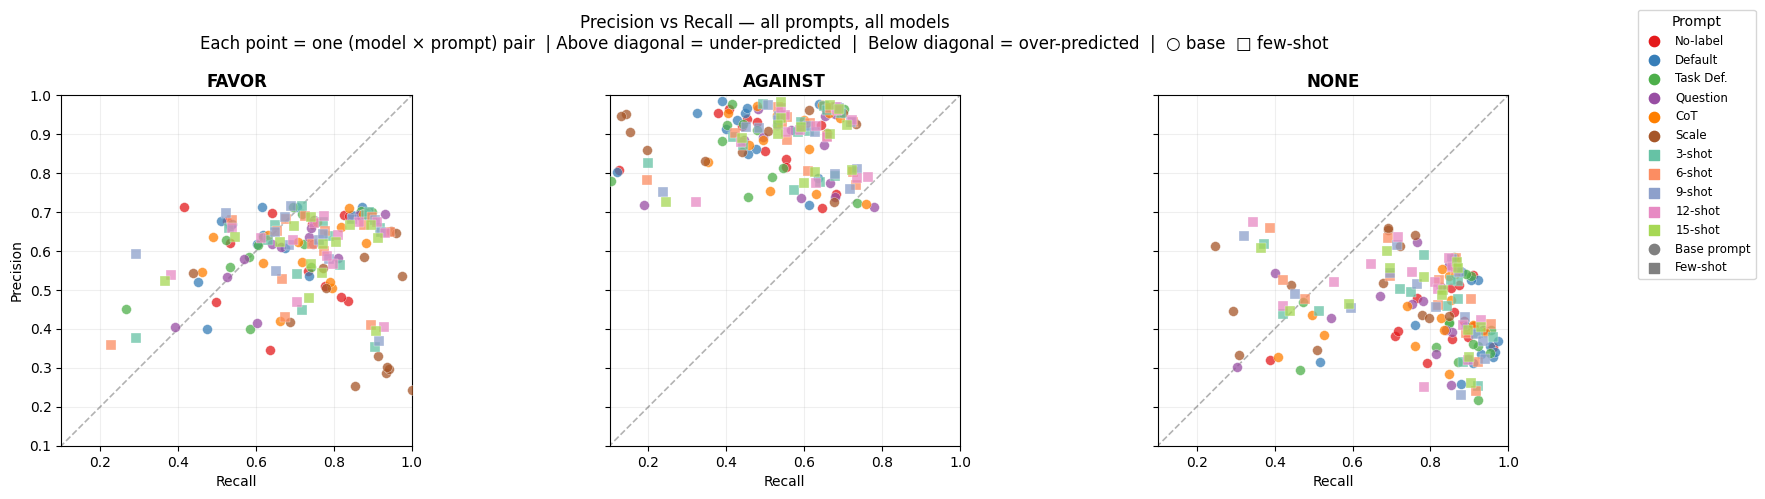

In [137]:
# ── 3.1  P vs R scatter — all (model × prompt) pairs ───────────────────────
# Each point = one (model, prompt) pair  →  154 points per class
# Colour = prompt  |  circle = base prompt, square = few-shot

FS_PROMPTS = ['few_shot_3','few_shot_6','few_shot_9','few_shot_12','few_shot_15']
ALL_PROMPT_COLORS = {p: c for p, c in zip(PROMPT_X_ORDER,
    ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628',
     '#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854'])}

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)

for ax, label in zip(axes, LABELS):
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1.2)

    for prompt, pname in zip(PROMPT_X_ORDER, PROMPT_X_LABELS):
        sub = bias_df[bias_df['prompt'] == prompt]
        mk  = 's' if prompt in FS_PROMPTS else 'o'
        ax.scatter(sub[f'r_{label}'], sub[f'p_{label}'],
                   color=ALL_PROMPT_COLORS[prompt],
                   marker=mk, s=50, alpha=0.75, zorder=3,
                   edgecolors='white', linewidths=0.3,
                   label=pname)

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_xlim(0.1, 1.0)
    ax.set_ylim(0.1, 1.0)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Precision')

handles = ([plt.scatter([], [], color=ALL_PROMPT_COLORS[p],
                        marker='s' if p in FS_PROMPTS else 'o',
                        s=55, label=n)
            for p, n in zip(PROMPT_X_ORDER, PROMPT_X_LABELS)]
         + [plt.scatter([], [], color='gray', marker='o', s=55, label='Base prompt'),
            plt.scatter([], [], color='gray', marker='s', s=55, label='Few-shot')])
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1),
           fontsize=8.5, frameon=True, title='Prompt')

plt.suptitle('Precision vs Recall — all prompts, all models\n'
             'Each point = one (model × prompt) pair  | Above diagonal = under-predicted  |  Below diagonal = over-predicted  |  ○ base  □ few-shot',
             fontsize=12)
plt.tight_layout()
plt.show()

In [138]:
# ── 3.2  Mean P / R / F1 per prompt — averaged across all models ────────────
prompt_tbl = (bias_df.groupby('prompt')
              [['p_FAVOR','r_FAVOR','f1_FAVOR',
                'p_AGAINST','r_AGAINST','f1_AGAINST',
                'p_NONE','r_NONE','f1_NONE','macro_f1']]
              .mean()
              .reindex(PROMPT_X_ORDER))

prompt_tbl.index = PROMPT_X_LABELS
prompt_tbl.columns = pd.MultiIndex.from_tuples([
    ('FAVOR','P'),('FAVOR','R'),('FAVOR','F1'),
    ('AGAINST','P'),('AGAINST','R'),('AGAINST','F1'),
    ('NONE','P'),('NONE','R'),('NONE','F1'),
    ('—','Macro F1'),
])

display(prompt_tbl.round(3).style
        .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=None)
        .set_caption('Mean P / R / F1 per prompt — averaged across all models')
        .set_table_styles([{'selector':'th','props':[('font-size','11px')]}]))

---
## 4. Per-Topic Analysis
Does model and prompt performance vary by topic?  
**Heatmap A** — mean macro F1 per model × topic (averaged across all prompts).  
**Heatmap B** — mean macro F1 per prompt × topic (averaged across all models).  
Topics: Atheism, Abortion, Climate Change, Feminist Movement, Hillary Clinton.

In [139]:
# ── 4.1  Load per-topic macro F1 for every (model, prompt) ──────────────────
from sklearn.metrics import f1_score as sk_f1

TOPIC_SHORT = {
    'Atheism':                          'Atheism',
    'Climate Change is a Real Concern': 'Climate',
    'Feminist Movement':                'Feminist',
    'Hillary Clinton':                  'Hillary',
    'Legalization of Abortion':         'Abortion',
}
ALL_PROMPTS_PT = [
    'default_no_label_definitions', 'default', 'task_definition',
    'question', 'cot', 'task_definition_scale',
    'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15',
]
SHORT_PROMPT_PT = {
    'default_no_label_definitions': 'No-label',
    'default':               'Default',
    'task_definition':       'Task Def.',
    'question':              'Question',
    'cot':                   'CoT',
    'task_definition_scale': 'Scale',
    'few_shot_3':  '3-shot',  'few_shot_6':  '6-shot',  'few_shot_9':  '9-shot',
    'few_shot_12': '12-shot', 'few_shot_15': '15-shot',
}

topic_f1_rows = []
seen_pt = set()
for folder in sorted(RUNS_ROOT.iterdir()):
    if not folder.is_dir() or '_testdata_gold_' not in folder.name:
        continue
    if not (folder / 'document_assignments.csv').exists():
        continue
    rest = folder.name.split('_testdata_gold_')[1]
    model_name, prompt_name = rest.split('_equal_', 1)
    if prompt_name not in ALL_PROMPTS_PT:
        continue
    if (model_name, prompt_name) in seen_pt:
        continue
    seen_pt.add((model_name, prompt_name))
    df = pd.read_csv(folder / 'document_assignments.csv',
                     usecols=['original_stance', 'predicted_stance', 'query'])
    df = df.dropna(subset=['predicted_stance'])
    if len(df) == 0:
        continue
    for topic, tgrp in df.groupby('query'):
        topic_short = TOPIC_SHORT.get(topic, topic)
        f1 = sk_f1(tgrp['original_stance'], tgrp['predicted_stance'],
                   labels=LABELS, average='macro', zero_division=0)
        f1_2class = sk_f1(tgrp['original_stance'], tgrp['predicted_stance'],
                          labels=['FAVOR', 'AGAINST'], average='macro', zero_division=0)
        topic_f1_rows.append({
            'model': model_name, 'prompt': prompt_name,
            'topic': topic_short,
            'macro_f1': f1, 'two_class_f1': f1_2class,
        })

topic_f1_df = pd.DataFrame(topic_f1_rows)
print(f"Loaded {len(topic_f1_df)} (model × prompt × topic) combinations")


Loaded 770 (model × prompt × topic) combinations


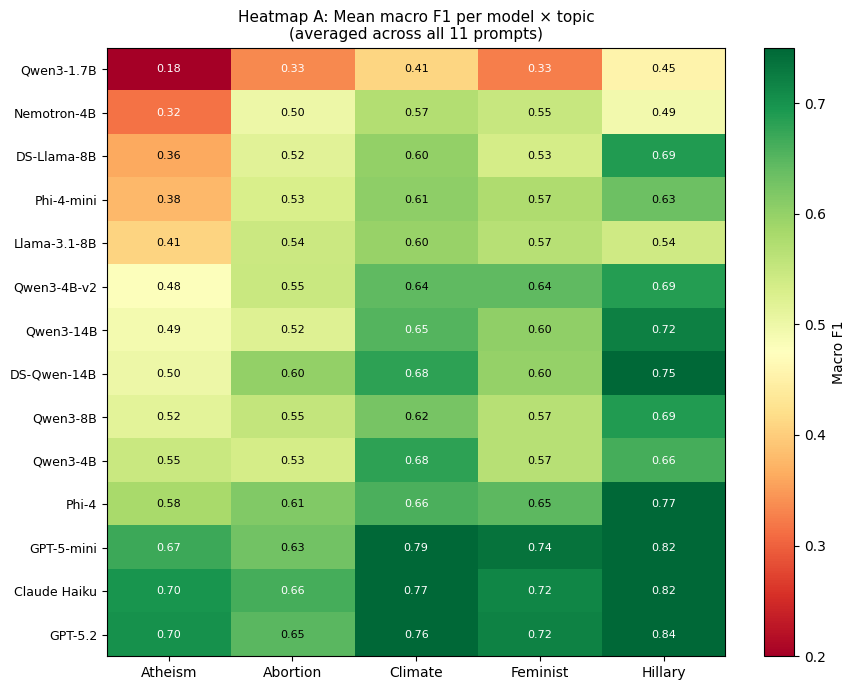

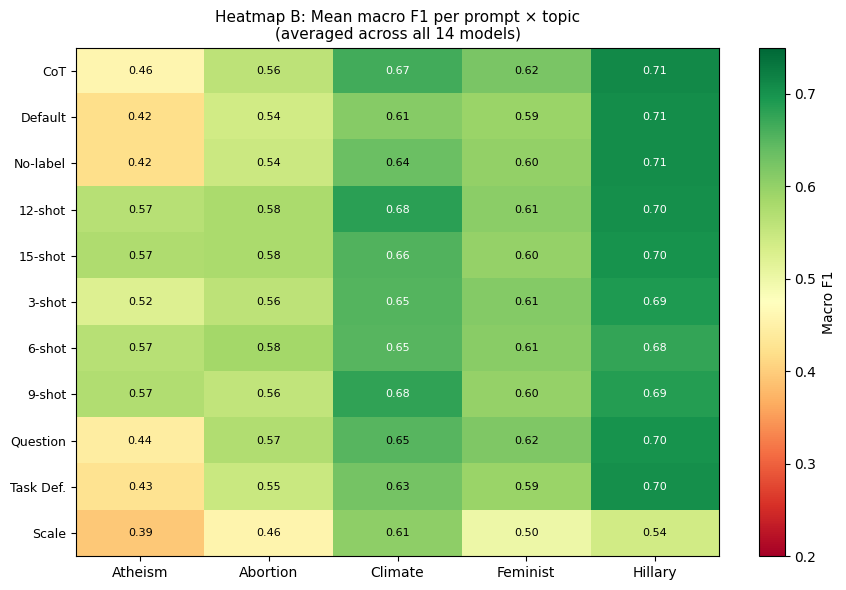

In [140]:
# ── 4.2  Heatmap A: model × topic  (mean macro F1, avg across all prompts) ───
TOPICS_ORDER = ['Atheism', 'Abortion', 'Climate', 'Feminist', 'Hillary']

model_topic = (topic_f1_df.groupby(['model', 'topic'])['macro_f1']
               .mean().unstack().reindex(columns=TOPICS_ORDER))
model_topic.index = [SHORT.get(m, m) for m in model_topic.index]
model_topic = model_topic.sort_values('Atheism')  # sort by one topic to group similar models

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(model_topic.values, cmap='RdYlGn', vmin=0.2, vmax=0.75, aspect='auto')
plt.colorbar(im, ax=ax, label='Macro F1')
ax.set_xticks(range(len(TOPICS_ORDER)))
ax.set_xticklabels(TOPICS_ORDER, fontsize=10)
ax.set_yticks(range(len(model_topic)))
ax.set_yticklabels(model_topic.index, fontsize=9)
for i in range(len(model_topic)):
    for j in range(len(TOPICS_ORDER)):
        val = model_topic.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if 0.35 < val < 0.65 else 'white')
ax.set_title('Heatmap A: Mean macro F1 per model × topic\n(averaged across all 11 prompts)', fontsize=11)
plt.tight_layout()
plt.show()

# ── 4.3  Heatmap B: prompt × topic  (mean macro F1, avg across all models) ───
prompt_topic = (topic_f1_df.groupby(['prompt', 'topic'])['macro_f1']
                .mean().unstack().reindex(columns=TOPICS_ORDER))
prompt_topic.index = [SHORT_PROMPT_PT.get(p, p) for p in prompt_topic.index]

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(prompt_topic.values, cmap='RdYlGn', vmin=0.2, vmax=0.75, aspect='auto')
plt.colorbar(im, ax=ax, label='Macro F1')
ax.set_xticks(range(len(TOPICS_ORDER)))
ax.set_xticklabels(TOPICS_ORDER, fontsize=10)
ax.set_yticks(range(len(prompt_topic)))
ax.set_yticklabels(prompt_topic.index, fontsize=9)
for i in range(len(prompt_topic)):
    for j in range(len(TOPICS_ORDER)):
        val = prompt_topic.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if 0.35 < val < 0.65 else 'white')
ax.set_title('Heatmap B: Mean macro F1 per prompt × topic\n(averaged across all 14 models)', fontsize=11)
plt.tight_layout()
plt.show()


### 4.2  Distribution & Atheism Deep Dive
**Chart 1** — F1 score distribution per topic across all model × prompt combinations (box plot).  
**Chart 2** — Atheism: predicted vs ground truth class distribution.  
**Chart 3** — Atheism: precision vs recall per class (where exactly models fail).

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_17928/650217313.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


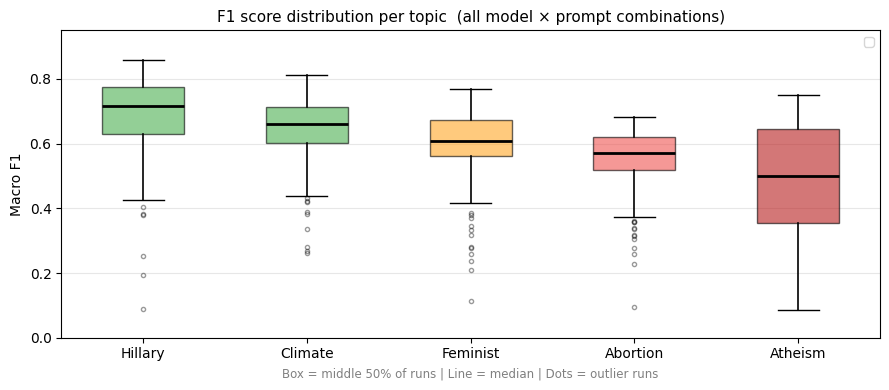

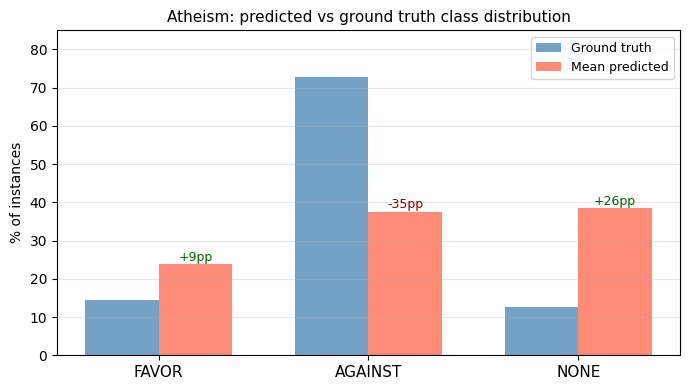

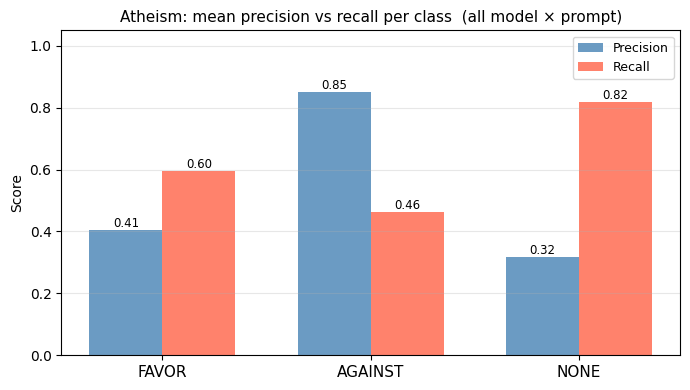

In [141]:
# ── 4.2  Per-topic F1 distribution + Atheism deep dive ───────────────────────
from sklearn.metrics import f1_score as sk_f1, classification_report

TOPICS_ORDER = ['Hillary', 'Climate', 'Feminist', 'Abortion', 'Atheism']
TOPIC_SHORT_LOCAL = {
    'Atheism': 'Atheism',
    'Climate Change is a Real Concern': 'Climate',
    'Feminist Movement': 'Feminist',
    'Hillary Clinton': 'Hillary',
    'Legalization of Abortion': 'Abortion',
}
ALL_PROMPTS_LOCAL = [
    'default_no_label_definitions', 'default', 'task_definition',
    'question', 'cot', 'task_definition_scale',
    'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15',
]

rows_bt = []
seen_bt = set()
for folder in sorted(RUNS_ROOT.iterdir()):
    if not folder.is_dir() or '_testdata_gold_' not in folder.name:
        continue
    if not (folder / 'document_assignments.csv').exists():
        continue
    rest = folder.name.split('_testdata_gold_')[1]
    model_name, prompt_name = rest.split('_equal_', 1)
    if prompt_name not in ALL_PROMPTS_LOCAL:
        continue
    if (model_name, prompt_name) in seen_bt:
        continue
    seen_bt.add((model_name, prompt_name))
    df = pd.read_csv(folder / 'document_assignments.csv',
                     usecols=['original_stance', 'predicted_stance', 'query'])
    df = df.dropna(subset=['predicted_stance'])
    if len(df) == 0:
        continue
    for topic, tgrp in df.groupby('query'):
        topic_s = TOPIC_SHORT_LOCAL.get(topic, topic)
        f1 = sk_f1(tgrp['original_stance'], tgrp['predicted_stance'],
                   labels=LABELS, average='macro', zero_division=0)
        rep = classification_report(tgrp['original_stance'], tgrp['predicted_stance'],
                                    labels=LABELS, output_dict=True, zero_division=0)
        pred_pct = tgrp['predicted_stance'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100
        gt_pct   = tgrp['original_stance'].value_counts(normalize=True).reindex(LABELS, fill_value=0) * 100
        row = {'model': model_name, 'prompt': prompt_name,
               'topic': topic_s, 'macro_f1': f1}
        for lbl in LABELS:
            row[f'p_{lbl}']        = rep[lbl]['precision']
            row[f'r_{lbl}']        = rep[lbl]['recall']
            row[f'pred_pct_{lbl}'] = pred_pct[lbl]
            row[f'gt_pct_{lbl}']   = gt_pct[lbl]
        rows_bt.append(row)

bt_df = pd.DataFrame(rows_bt)

# ── Chart 1: Box plot — F1 distribution per topic ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
data_by_topic = [bt_df[bt_df['topic'] == t]['macro_f1'].values for t in TOPICS_ORDER]
bp = ax.boxplot(data_by_topic, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4, color='gray'))
colors = ['#4CAF50', '#4CAF50', '#FFA726', '#EF5350', '#B71C1C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_xticks(range(1, len(TOPICS_ORDER) + 1))
ax.set_xticklabels(TOPICS_ORDER, fontsize=10)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 0.95)
ax.set_title('F1 score distribution per topic  (all model × prompt combinations)', fontsize=11)
ax.set_xlabel('Box = middle 50% of runs | Line = median | Dots = outlier runs', fontsize=8.5, color='gray')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Chart 2: Atheism — predicted vs ground truth distribution ────────────────
ath = bt_df[bt_df['topic'] == 'Atheism']
gt_means   = {lbl: ath[f'gt_pct_{lbl}'].mean()   for lbl in LABELS}
pred_means = {lbl: ath[f'pred_pct_{lbl}'].mean() for lbl in LABELS}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(LABELS))
w = 0.35
gt_vals   = [gt_means[l]   for l in LABELS]
pred_vals = [pred_means[l] for l in LABELS]
ax.bar(x - w/2, gt_vals,   w, label='Ground truth', color='steelblue',  alpha=0.75)
ax.bar(x + w/2, pred_vals, w, label='Mean predicted', color='tomato', alpha=0.75)
for i, (g, p) in enumerate(zip(gt_vals, pred_vals)):
    diff = p - g
    ax.text(i + w/2, p + 0.8, f'{diff:+.0f}pp', ha='center', fontsize=9,
            color='darkred' if diff < 0 else 'darkgreen')
ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_ylabel('% of instances')
ax.set_ylim(0, 85)
ax.set_title('Atheism: predicted vs ground truth class distribution', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Chart 3: Atheism — precision vs recall per class ─────────────────────────
p_means = [ath[f'p_{lbl}'].mean() for lbl in LABELS]
r_means = [ath[f'r_{lbl}'].mean() for lbl in LABELS]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, p_means, w, label='Precision', color='steelblue', alpha=0.80)
ax.bar(x + w/2, r_means, w, label='Recall',    color='tomato',    alpha=0.80)
for i, (p, r) in enumerate(zip(p_means, r_means)):
    ax.text(i - w/2, p + 0.01, f'{p:.2f}', ha='center', fontsize=8.5)
    ax.text(i + w/2, r + 0.01, f'{r:.2f}', ha='center', fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Atheism: mean precision vs recall per class  (all model × prompt)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 4.3  Per-model Performance Across Topics

Each line is one model; x-axis = topic ordered easy→hard. Shows whether the Atheism gap is universal or model-specific.


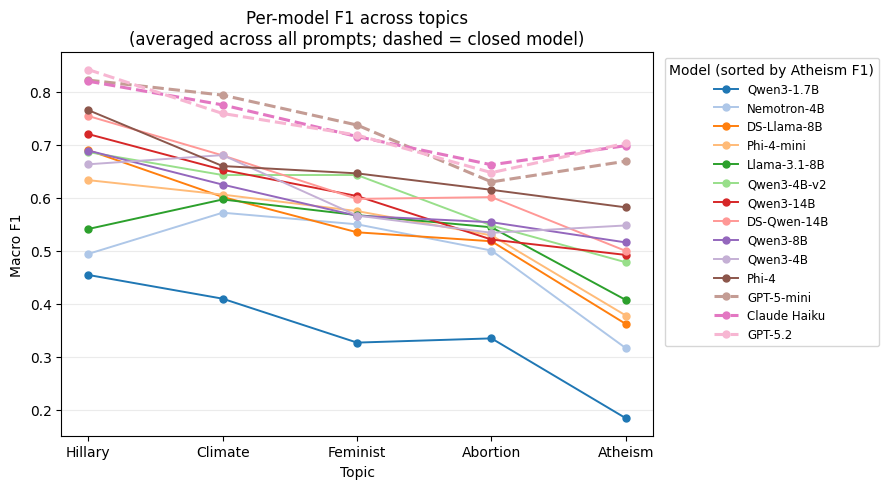

In [142]:
# ── 4.3  Per-model F1 across topics — which models struggle on Atheism? ────────
import matplotlib.cm as cm

TOPICS_LINE = ['Hillary', 'Climate', 'Feminist', 'Abortion', 'Atheism']

# Mean macro F1 per (model, topic), averaged across all prompts
model_topic = (topic_f1_df.groupby(['model', 'topic'])['macro_f1']
               .mean().unstack()[TOPICS_LINE])

# Sort models by Atheism F1 ascending — worst at top, best at bottom in legend
model_order = model_topic['Atheism'].sort_values().index.tolist()

# Color: closed models get distinct markers; open models get a gradient
n = len(model_order)
palette = cm.tab20.colors

fig, ax = plt.subplots(figsize=(9, 5))

for i, model in enumerate(model_order):
    label = SHORT.get(model, model)
    is_closed = model in CLOSED
    lw   = 2.2 if is_closed else 1.4
    ls   = '--' if is_closed else '-'
    color = palette[i % len(palette)]
    ax.plot(TOPICS_LINE, model_topic.loc[model, TOPICS_LINE],
            color=color, linewidth=lw, linestyle=ls,
            marker='o', markersize=5, label=label, zorder=3)

ax.set_xlabel('Topic')
ax.set_ylabel('Macro F1')
ax.set_title('Per-model F1 across topics\n(averaged across all prompts; dashed = closed model)')
ax.grid(True, axis='y', alpha=0.25)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1),
          fontsize=8.5, frameon=True, title='Model (sorted by Atheism F1)')
plt.tight_layout()
plt.show()


In [143]:
# ── Results Summary ──────────────────────────────────────────────────────────
print("=" * 65)
print("STANCE DETECTION — SUMMARY OF KEY FINDINGS")
print("=" * 65)

# Best model by 3-class macro F1 (avg across all prompts)
model_avg = bias_df.groupby('model')['macro_f1'].mean().sort_values(ascending=False)
best_model = model_avg.index[0]
print(f"\n3-CLASS MACRO F1")
print(f"  Best model (avg across prompts): {SHORT.get(best_model, best_model):<20} {model_avg.iloc[0]:.3f}")
print(f"  Worst model:                     {SHORT.get(model_avg.index[-1], model_avg.index[-1]):<20} {model_avg.iloc[-1]:.3f}")

# Best prompt by 3-class macro F1
prompt_avg = bias_df.groupby('prompt')['macro_f1'].mean().sort_values(ascending=False)
best_prompt = prompt_avg.index[0]
print(f"  Best prompt (avg across models): {SHORT_PROMPT.get(best_prompt, best_prompt):<20} {prompt_avg.iloc[0]:.3f}")

# Baseline comparison
two_class_avg = two_class_df.groupby('model')['two_class_f1'].mean()
print(f"\n2-CLASS F1  (Mohammad et al. baseline = 0.6782)")
for m in two_class_avg.sort_values(ascending=False).index[:5]:
    flag = " ✓ BEATS BASELINE" if two_class_avg[m] > 0.6782 else ""
    print(f"  {SHORT.get(m, m):<22} {two_class_avg[m]:.3f}{flag}")

# Homogenization bias
print(f"\nHOMOGENIZATION BIAS  (mean predicted − ground truth)")
for label in ['FAVOR', 'AGAINST', 'NONE']:
    bias = bias_df[f'bias_{label}'].mean()
    print(f"  {label:<10}  {bias:+.1f} pp")

# P/R signature
print(f"\nPRECISION / RECALL SIGNATURE  (mean across all model × prompt)")
for label in ['FAVOR', 'AGAINST', 'NONE']:
    p = bias_df[f'p_{label}'].mean()
    r = bias_df[f'r_{label}'].mean()
    f = bias_df[f'f1_{label}'].mean()
    sig = "P>R (under-pred)" if p > r else "P<R (over-pred)"
    print(f"  {label:<10}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  → {sig}")

# Per-topic
print(f"\nPER-TOPIC MACRO F1  (mean across all models × prompts)")
topic_avg = topic_f1_df.groupby('topic')['macro_f1'].mean().sort_values()
for t, v in topic_avg.items():
    print(f"  {t:<12}  {v:.3f}")

print("\n" + "=" * 65)


STANCE DETECTION — SUMMARY OF KEY FINDINGS

3-CLASS MACRO F1
  Best model (avg across prompts): Claude Haiku         0.747
  Worst model:                     Qwen3-1.7B           0.359
  Best prompt (avg across models): 12-shot              0.647

2-CLASS F1  (Mohammad et al. baseline = 0.6782)
  Claude Haiku           0.787 ✓ BEATS BASELINE
  GPT-5.2                0.779 ✓ BEATS BASELINE
  GPT-5-mini             0.777 ✓ BEATS BASELINE
  Phi-4                  0.705 ✓ BEATS BASELINE
  DS-Qwen-14B            0.677

HOMOGENIZATION BIAS  (mean predicted − ground truth)
  FAVOR       +7.1 pp
  AGAINST     -22.1 pp
  NONE        +15.0 pp

PRECISION / RECALL SIGNATURE  (mean across all model × prompt)
  FAVOR       P=0.590  R=0.722  F1=0.635  → P<R (over-pred)
  AGAINST     P=0.878  R=0.539  F1=0.651  → P>R (under-pred)
  NONE        P=0.448  R=0.759  F1=0.542  → P<R (over-pred)

PER-TOPIC MACRO F1  (mean across all models × prompts)
  Atheism       0.488
  Abortion      0.553
  Feminist    